<a href="https://www.kaggle.com/code/sonawanelalitsunil/marriage-trends-in-india-ml-89-3?scriptVersionId=227313379" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/marriage-trends-in-india-love-vs-arranged/marriage_data_india.csv


## Title : "Marriage Trends in India: Love vs. Arranged – A Changing Landscape" 

**Overview** 

**Marriage has been a cornerstone of Indian society for centuries, traditionally dominated by arranged marriages. However, with modernization, urbanization, and shifting cultural values, love marriages have been steadily gaining acceptance. This shift is influenced by factors such as education, economic independence, digital matchmaking, and changing family dynamics.**

Modern Trends in India:

Rise of Online Matrimonial Platforms – Websites like Shaadi.com & BharatMatrimony are blending tradition with technology.

Inter-caste & Inter-religious Marriages – Increasing but still facing societal resistance.

Love-Arranged Hybrid Marriages – Young couples introduce partners to families for arranged approval.

Urban vs. Rural Divide – Love marriages are more common in urban areas, while rural regions remain traditional.

Changing Gender Roles – Women are more financially independent, influencing marital choices.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/marriage-trends-in-india-love-vs-arranged/marriage_data_india.csv')

In [3]:
df.head()

,ID,Marriage_Type,Age_at_Marriage,Gender,Education_Level,Caste_Match,Religion,Parental_Approval,Urban_Rural,Dowry_Exchanged,Marital_Satisfaction,Divorce_Status,Children_Count,Income_Level,Years_Since_Marriage,Spouse_Working,Inter-Caste,Inter-Religion
0,1,Love,23,Male,Graduate,Different,Hindu,No,Urban,No,Medium,Yes,5,Middle,34,No,No,No
1,2,Love,28,Female,School,Same,Hindu,Yes,Rural,Yes,Low,No,3,Middle,42,No,No,Yes
2,3,Arranged,39,Male,Postgraduate,Same,Muslim,Yes,Rural,No,Medium,No,0,High,25,No,No,No
3,4,Arranged,26,Female,School,Different,Hindu,Yes,Urban,Yes,Low,No,0,High,12,No,Yes,No
4,5,Love,32,Female,Graduate,Same,Hindu,Partial,Rural,Yes,Medium,No,1,Middle,41,No,No,Yes


In [4]:
df.tail()

,ID,Marriage_Type,Age_at_Marriage,Gender,Education_Level,Caste_Match,Religion,Parental_Approval,Urban_Rural,Dowry_Exchanged,Marital_Satisfaction,Divorce_Status,Children_Count,Income_Level,Years_Since_Marriage,Spouse_Working,Inter-Caste,Inter-Religion
9995,9996,Love,25,Male,Postgraduate,Different,Hindu,Yes,Urban,Not Disclosed,Medium,No,5,Low,38,Yes,No,No
9996,9997,Arranged,31,Female,School,Same,Hindu,Partial,Rural,No,High,No,4,Low,1,No,No,No
9997,9998,Love,22,Male,Graduate,Same,Hindu,Partial,Rural,Yes,Medium,No,2,Low,24,No,Yes,No
9998,9999,Arranged,39,Male,Postgraduate,Same,Muslim,Yes,Urban,No,Medium,No,3,Middle,28,No,No,No
9999,10000,Arranged,36,Male,School,Different,Hindu,Partial,Urban,Yes,High,No,3,Middle,7,Yes,No,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    10000 non-null  int64 
 1   Marriage_Type         10000 non-null  object
 2   Age_at_Marriage       10000 non-null  int64 
 3   Gender                10000 non-null  object
 4   Education_Level       10000 non-null  object
 5   Caste_Match           10000 non-null  object
 6   Religion              10000 non-null  object
 7   Parental_Approval     10000 non-null  object
 8   Urban_Rural           10000 non-null  object
 9   Dowry_Exchanged       10000 non-null  object
 10  Marital_Satisfaction  10000 non-null  object
 11  Divorce_Status        10000 non-null  object
 12  Children_Count        10000 non-null  int64 
 13  Income_Level          10000 non-null  object
 14  Years_Since_Marriage  10000 non-null  int64 
 15  Spouse_Working        10000 non-null 

In [6]:
df.describe()

,ID,Age_at_Marriage,Children_Count,Years_Since_Marriage
count,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,28.503800,2.508800,24.973800
std,2886.89568,6.279564,1.695467,14.054838
min,1.00000,18.000000,0.000000,1.000000
25%,2500.75000,23.000000,1.000000,13.000000
50%,5000.50000,29.000000,3.000000,25.000000
75%,7500.25000,34.000000,4.000000,37.000000
max,10000.00000,39.000000,5.000000,49.000000


In [7]:
df.isnull().sum()

ID                      0
Marriage_Type           0
Age_at_Marriage         0
Gender                  0
Education_Level         0
Caste_Match             0
Religion                0
Parental_Approval       0
Urban_Rural             0
Dowry_Exchanged         0
Marital_Satisfaction    0
Divorce_Status          0
Children_Count          0
Income_Level            0
Years_Since_Marriage    0
Spouse_Working          0
Inter-Caste             0
Inter-Religion          0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.corr

<bound method DataFrame.corr of          ID Marriage_Type  Age_at_Marriage  Gender Education_Level  \
0         1          Love               23    Male        Graduate   
1         2          Love               28  Female          School   
2         3      Arranged               39    Male    Postgraduate   
3         4      Arranged               26  Female          School   
4         5          Love               32  Female        Graduate   
...     ...           ...              ...     ...             ...   
9995   9996          Love               25    Male    Postgraduate   
9996   9997      Arranged               31  Female          School   
9997   9998          Love               22    Male        Graduate   
9998   9999      Arranged               39    Male    Postgraduate   
9999  10000      Arranged               36    Male          School   

     Caste_Match Religion Parental_Approval Urban_Rural Dowry_Exchanged  \
0      Different    Hindu                No       Ur

In [10]:
df.dtypes

ID                       int64
Marriage_Type           object
Age_at_Marriage          int64
Gender                  object
Education_Level         object
Caste_Match             object
Religion                object
Parental_Approval       object
Urban_Rural             object
Dowry_Exchanged         object
Marital_Satisfaction    object
Divorce_Status          object
Children_Count           int64
Income_Level            object
Years_Since_Marriage     int64
Spouse_Working          object
Inter-Caste             object
Inter-Religion          object
dtype: object

In [11]:
df.shape

(10000, 18)

In [12]:
df.columns

Index(['ID', 'Marriage_Type', 'Age_at_Marriage', 'Gender', 'Education_Level',
       'Caste_Match', 'Religion', 'Parental_Approval', 'Urban_Rural',
       'Dowry_Exchanged', 'Marital_Satisfaction', 'Divorce_Status',
       'Children_Count', 'Income_Level', 'Years_Since_Marriage',
       'Spouse_Working', 'Inter-Caste', 'Inter-Religion'],
      dtype='object')

## Data visualizations

In [13]:
# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Distribution of Marriage Types')

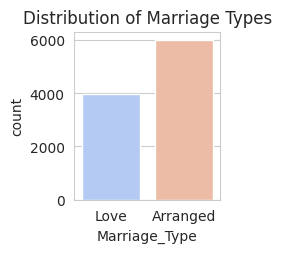

In [14]:
# 1️⃣ Marriage Type Distribution
plt.subplot(2, 3, 1)
sns.countplot(data=df, x="Marriage_Type", palette="coolwarm")
plt.title("Distribution of Marriage Types")

Text(0.5, 1.0, 'Age at Marriage by Gender')

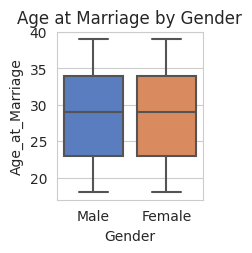

In [15]:
# 2️⃣ Age at Marriage by Gender
plt.subplot(2, 3, 2)
sns.boxplot(data=df, x="Gender", y="Age_at_Marriage", palette="muted")
plt.title("Age at Marriage by Gender")

Text(0, 0.5, 'Percentage (%)')

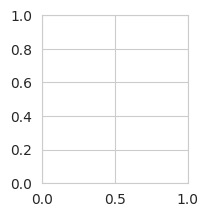

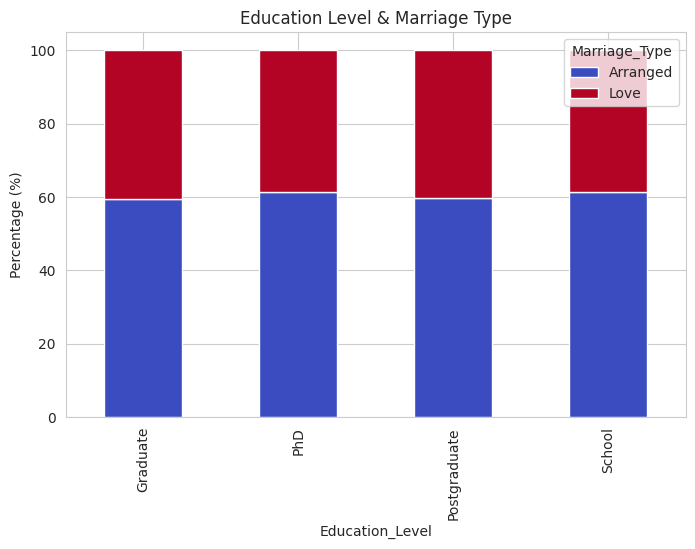

In [16]:

# 3️⃣ Education Level & Marriage Type
plt.subplot(2, 3, 3)
edu_marriage = pd.crosstab(df["Education_Level"], df["Marriage_Type"], normalize="index") * 100
edu_marriage.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(8, 5))
plt.title("Education Level & Marriage Type")
plt.ylabel("Percentage (%)")

Text(0.5, 1.0, 'Parental Approval Trends')

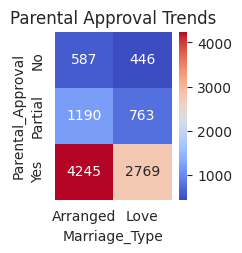

In [17]:
# 4️⃣ Parental Approval & Marriage Type
plt.subplot(2, 3, 4)
approval_marriage = pd.crosstab(df["Parental_Approval"], df["Marriage_Type"])
sns.heatmap(approval_marriage, annot=True, cmap="coolwarm", fmt="d")
plt.title("Parental Approval Trends")

Text(0.5, 1.0, 'Marital Satisfaction & Divorce Rate')

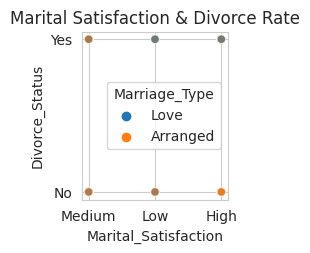

In [18]:
# 5️⃣ Marital Satisfaction vs Divorce Rate
plt.subplot(2, 3, 5)
sns.scatterplot(data=df, x="Marital_Satisfaction", y="Divorce_Status", hue="Marriage_Type", alpha=0.6)
plt.title("Marital Satisfaction & Divorce Rate")


In [19]:
print(df["Marriage_Type"].value_counts(dropna=False))


Marriage_Type
Arranged    6022
Love        3978
Name: count, dtype: int64


In [20]:
df = df.dropna(subset=["Marriage_Type"])

In [21]:
df["Marriage_Type"].fillna("Unknown", inplace=True)

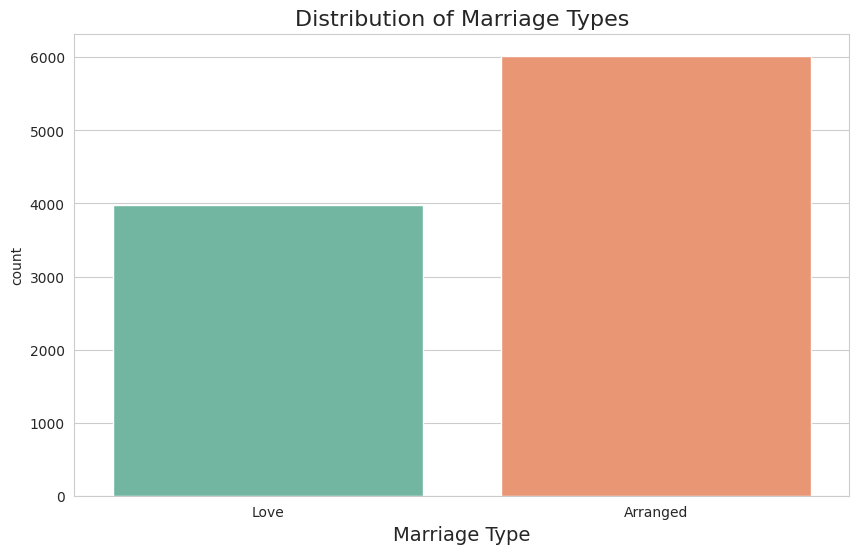

In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(x="Marriage_Type", data=df, palette="Set2")
plt.title("Distribution of Marriage Types", fontsize=16)
plt.xlabel("Marriage Type", fontsize=14)
plt.show()


In [23]:
import matplotlib.ticker as mtick

Education Level by Marriage Type (%):
 Marriage_Type     Arranged       Love
Education_Level                      
School           31.301893  29.864253
Graduate         38.890734  40.246355
Postgraduate     19.976752  20.487682
PhD               9.830621   9.401709


<Figure size 1200x800 with 0 Axes>

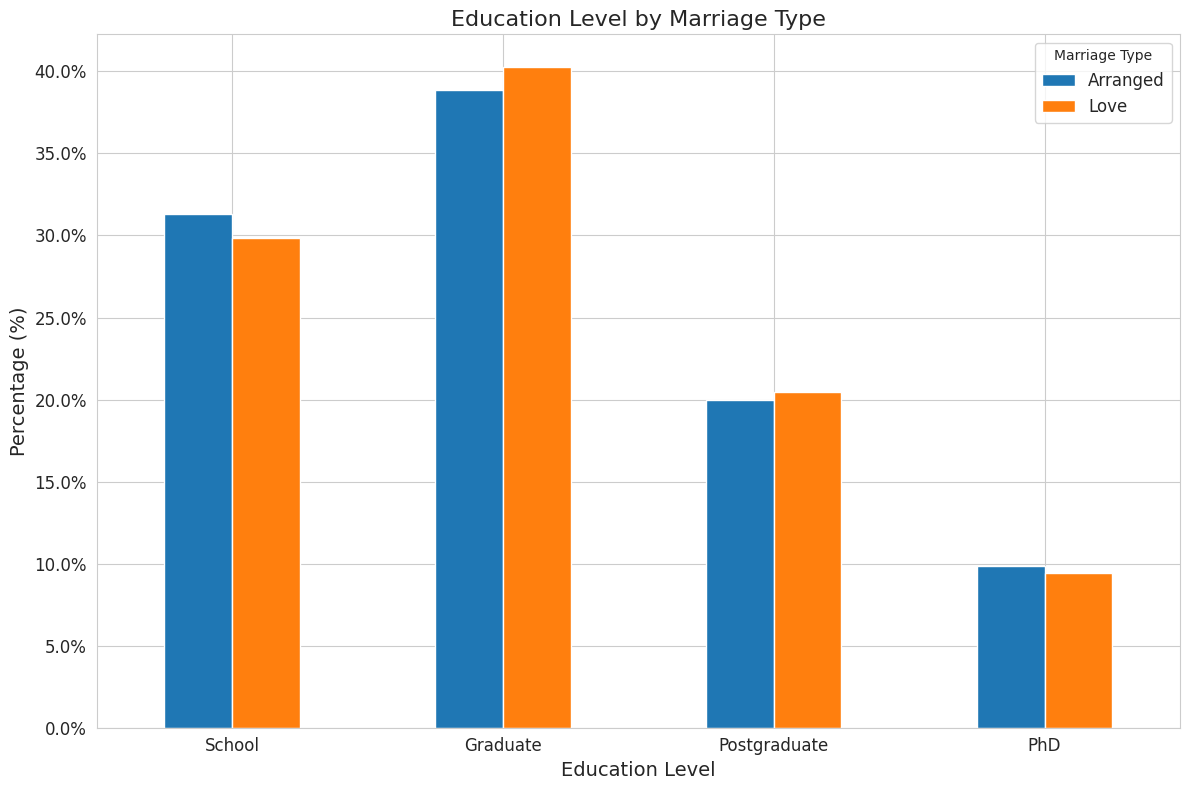

In [24]:
# Define order of education levels
education_order = ['School', 'Graduate', 'Postgraduate', 'PhD']

# Compute percentage distribution
cross_tab = pd.crosstab(df['Education_Level'], df['Marriage_Type'], normalize='columns') * 100
cross_tab = cross_tab.reindex(education_order)

# Display cross-tabulation
print("Education Level by Marriage Type (%):\n", cross_tab)

# Plot
plt.figure(figsize=(12, 8))
cross_tab.plot(kind='bar', figsize=(12, 8), rot=0)
plt.title('Education Level by Marriage Type', fontsize=16)
plt.xlabel('Education Level', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Marriage Type', fontsize=12)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

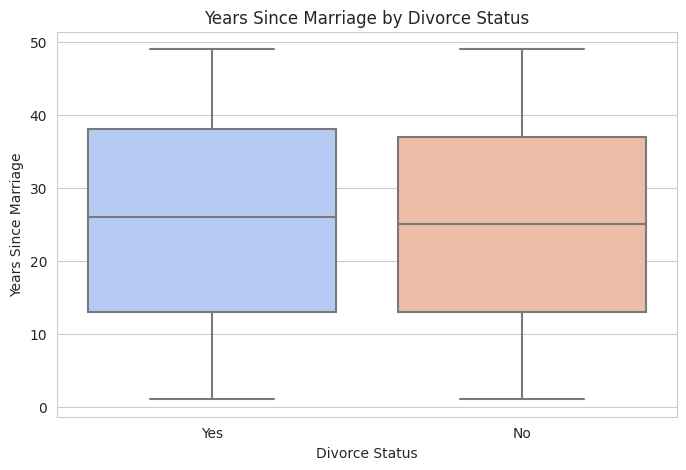

In [25]:
plt.figure(figsize=(8, 5))

# Ensure correct column names
sns.boxplot(x='Divorce_Status', y='Years_Since_Marriage', data=df, palette='coolwarm')

plt.title('Years Since Marriage by Divorce Status')
plt.xlabel('Divorce Status')
plt.ylabel('Years Since Marriage')
plt.show()


## predictive Modeling

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [27]:
df_model = df.drop(['ID'], axis=1)

In [28]:
print(df_model.columns)

Index(['Marriage_Type', 'Age_at_Marriage', 'Gender', 'Education_Level',
       'Caste_Match', 'Religion', 'Parental_Approval', 'Urban_Rural',
       'Dowry_Exchanged', 'Marital_Satisfaction', 'Divorce_Status',
       'Children_Count', 'Income_Level', 'Years_Since_Marriage',
       'Spouse_Working', 'Inter-Caste', 'Inter-Religion'],
      dtype='object')


In [29]:
X = df.drop(['ID', 'Marriage_Type'], axis=1)
y = df['Marriage_Type']

# Convert categorical variables to binary using one-hot encoding
categorical_cols = ['Gender', 'Education_Level', 'Caste_Match', 'Religion', 
                   'Parental_Approval', 'Urban_Rural', 'Dowry_Exchanged',
                   'Marital_Satisfaction', 'Divorce_Status', 'Income_Level', 
                   'Spouse_Working', 'Inter-Caste', 'Inter-Religion', 
                   'Age_Group', 'Marriage_Duration_Group']

numeric_cols = ['Age_at_Marriage', 'Children_Count', 'Years_Since_Marriage']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

In [30]:
from sklearn.metrics import accuracy_score

categorical_features = df_model.select_dtypes(include=['object']).columns.tolist()

# One-hot encode categorical variables
df_model = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)

print('Columns used for modeling:')
print(df_model.columns.tolist())

# Set target variable correctly
y = df_model['Divorce_Status_Yes']

# Drop the correct column from features
X = df_model.drop(['Divorce_Status_Yes'], axis=1)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate and train a RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Prediction Accuracy:', accuracy)

Columns used for modeling:
['Age_at_Marriage', 'Children_Count', 'Years_Since_Marriage', 'Marriage_Type_Love', 'Gender_Male', 'Education_Level_PhD', 'Education_Level_Postgraduate', 'Education_Level_School', 'Caste_Match_Same', 'Religion_Hindu', 'Religion_Muslim', 'Religion_Others', 'Religion_Sikh', 'Parental_Approval_Partial', 'Parental_Approval_Yes', 'Urban_Rural_Urban', 'Dowry_Exchanged_Not Disclosed', 'Dowry_Exchanged_Yes', 'Marital_Satisfaction_Low', 'Marital_Satisfaction_Medium', 'Divorce_Status_Yes', 'Income_Level_Low', 'Income_Level_Middle', 'Spouse_Working_Yes', 'Inter-Caste_Yes', 'Inter-Religion_Yes']
Prediction Accuracy: 0.893


## Thank you....Upvotes pls!!!!!!!